In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import skleaSSrn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams["figure.figsize"] = [10,5]


# Ignore warnings`

import warnings
# Set the warning filter to ignore FutureWarning
warnings.simplefilter(action = "ignore", category = FutureWarning)

In [ ]:
full_data = pd.read_csv('/content/titanic_dataset.csv')

In [ ]:
full_data.shape

(891, 12)

In [ ]:
full_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


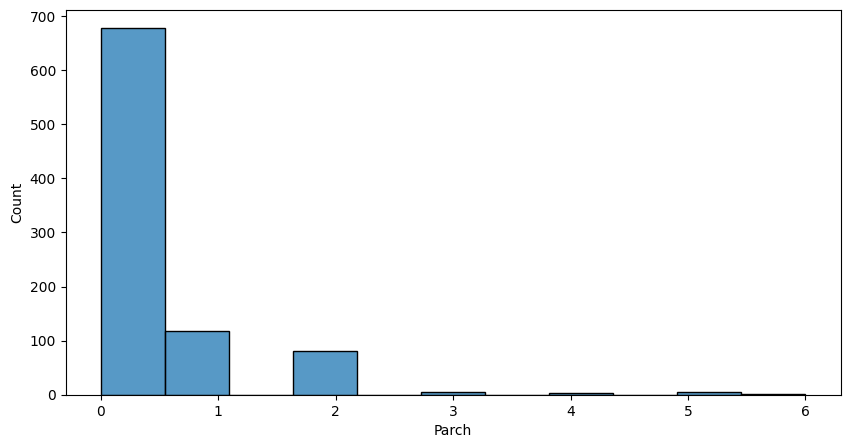

In [ ]:
sns.histplot(full_data['Parch'],kde=False)
plt.show()

**As we can see, most passengers don't have neither parents nor children aboard.**

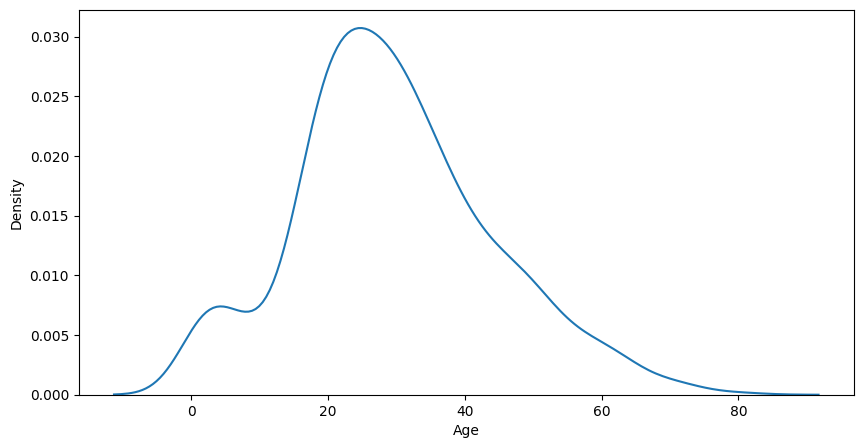

In [ ]:
sns.distplot(full_data['Age'], hist=False)
plt.show()

**As we can see that most of the passenger has the age between 20 to 40**

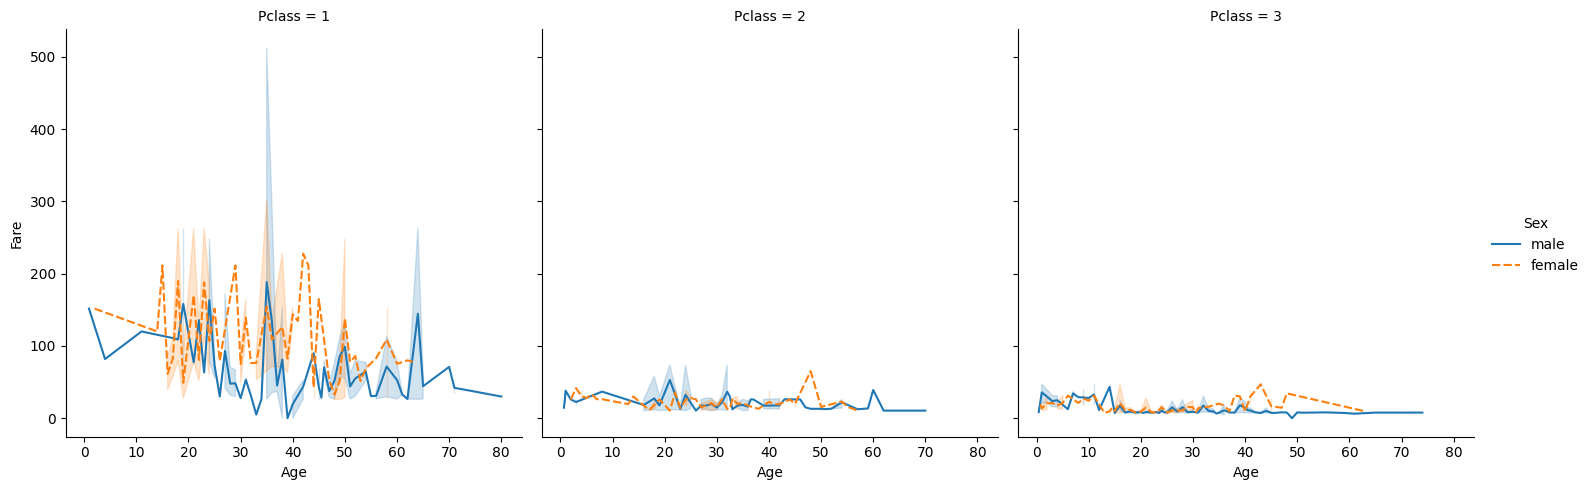

In [ ]:
sns.relplot(x="Age", y="Fare", col="Pclass", hue="Sex", style="Sex",kind="line", data=full_data) # scatter can be used instead of "line" plot
plt.show()

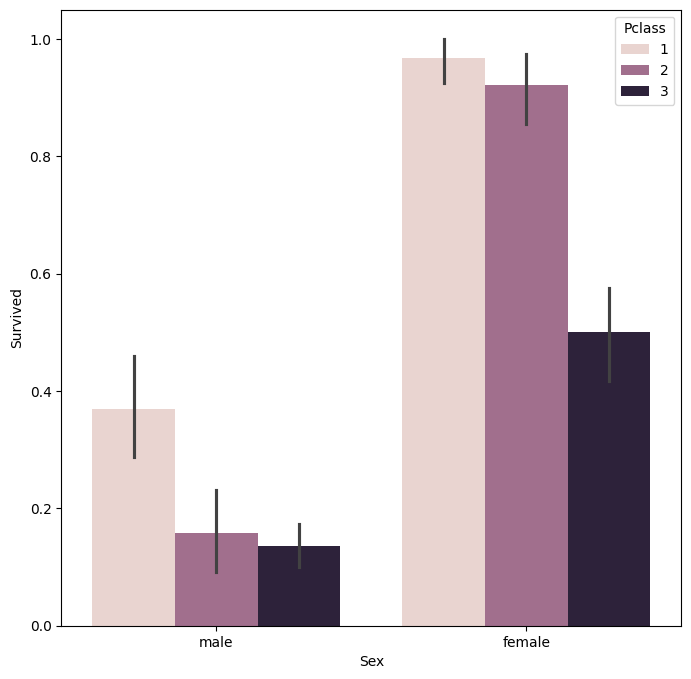

In [ ]:
plt.figure(figsize=(8,8))
sns.barplot(x="Sex", y="Survived", hue="Pclass", data=full_data)
plt.show()

**As we can see, More women survived than men.**


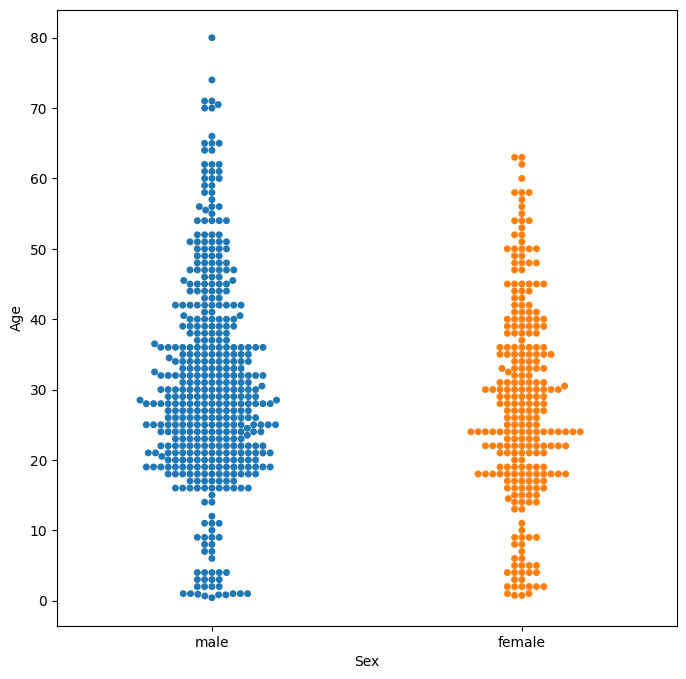

In [ ]:
plt.figure(figsize=(8,8))
sns.swarmplot(x="Sex", y="Age",hue='Sex', data=full_data)
plt.show()

**We can said that more passengers are approximally between 18 and 40 years old.**


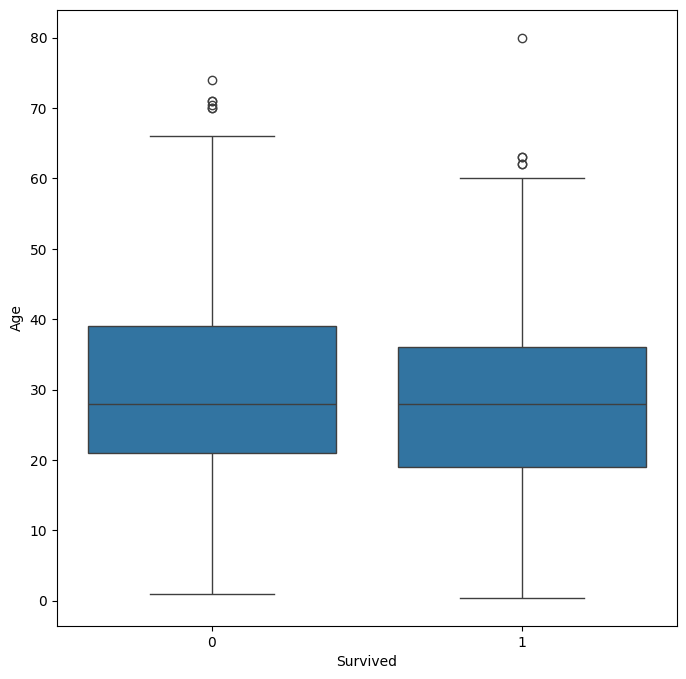

In [ ]:
plt.figure(figsize=(8,8))
sns.boxplot(x="Survived", y="Age", data=full_data)
plt.show()

**We have some outliers for passengers survery through their age.**


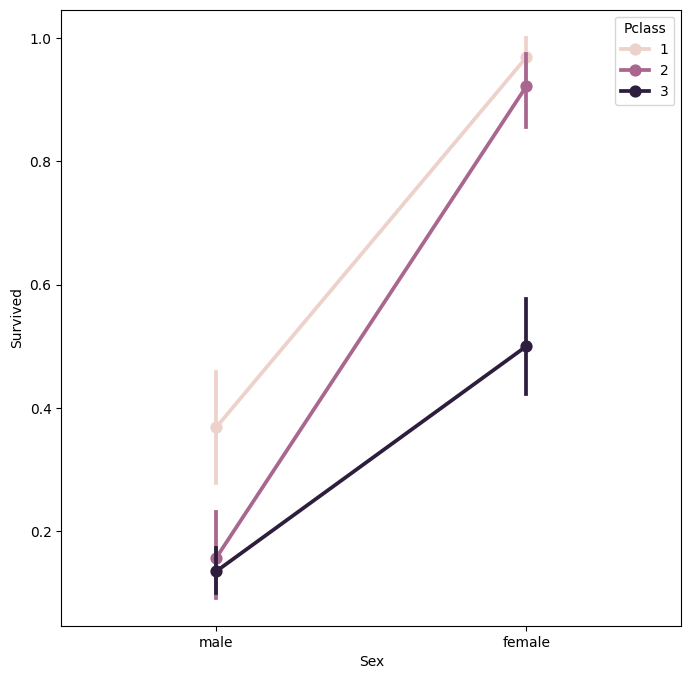

In [ ]:
plt.subplots(figsize=(8, 8))
sns.pointplot(x="Sex", y="Survived", hue="Pclass", data=full_data)
plt.show()

**We can see the average number of survivals of male and female in each class. From the plot we can understand that more number of females survived than males. In both males and females more number of survivals are from first
class.**


In [ ]:
# Data Info
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Missing Data**  
From the entry totals above, there appears to be missing data.  A heatmap will help better visualize what features as missing the most information.

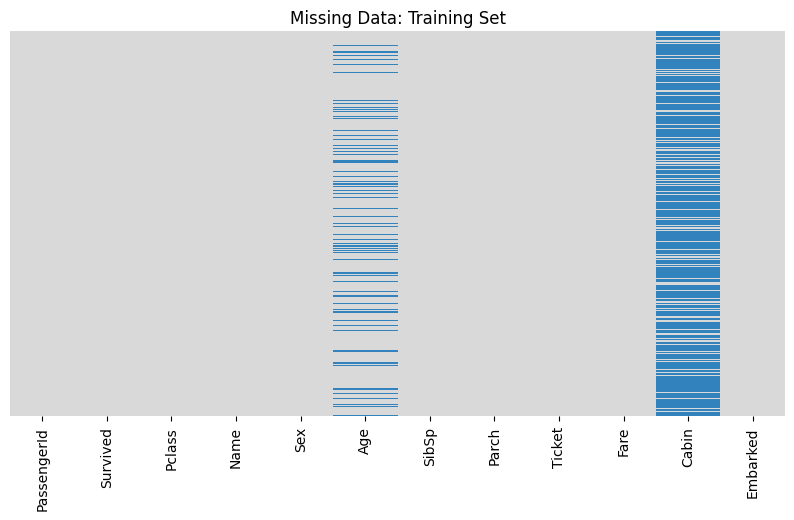

In [ ]:
# Heatmap
sns.heatmap(full_data.isnull(),yticklabels = False, cbar = False,cmap = 'tab20c_r')
plt.title('Missing Data: Training Set')
plt.show()

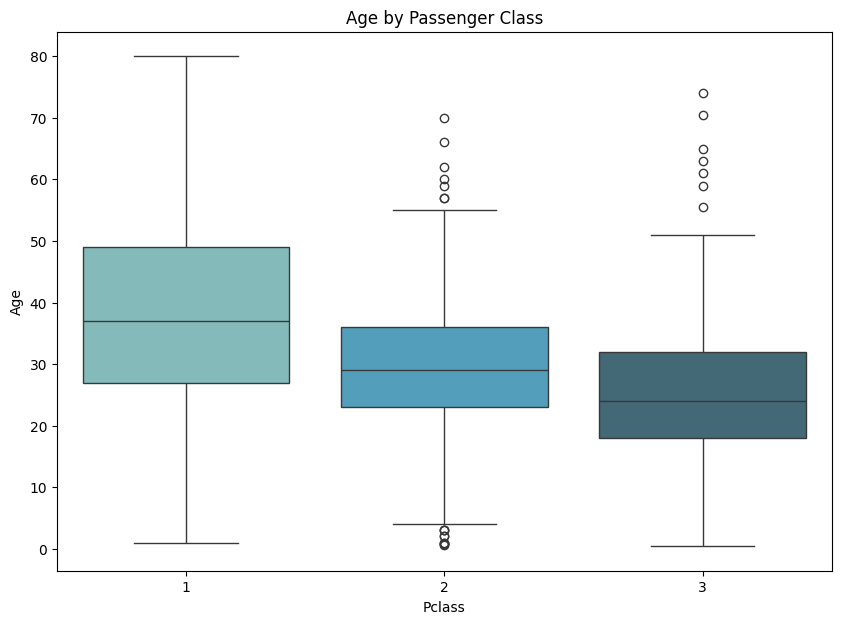

In [ ]:
plt.figure(figsize = (10,7))
sns.boxplot(x = 'Pclass', y = 'Age', data = full_data, palette= 'GnBu_d').set_title('Age by Passenger Class')
plt.show()

Naturally, the wealthier passengers in the higher classes tend to be older . We'll use these average age values to impute based on Pclass for Age.


In [ ]:
# Imputation function
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 37

        elif Pclass == 2:

            return 29

        else:
            return 24

    else:
        return Age

# Apply the function to the Age column
full_data['Age']=full_data[['Age','Pclass']].apply(impute_age, axis =1 )


The Cabin column has too many missing values to do anything useful with, so it would be best to remove it from the data frame altogether.

In [ ]:
# Remove Cabin feature
full_data.drop('Cabin', axis = 1, inplace = True)

Since there is only one missing value in Embarked, that observation can just be removed.

In [ ]:
# Remove rows with missing data
full_data.dropna(inplace = True)

Name and Ticket can be removed from the dataset as these features do not provide additional information about a passenger's liklihood of survival.    

The remaining non-null objects, Sex and Embarked, will need to be specified as categories for better analysis results downstream.  

In [ ]:
full_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [ ]:
# Remove unnecessary columns
full_data.drop(['Name','Ticket'], axis = 1, inplace = True)

# Convert objects to category data type
objcat = ['Sex','Embarked']

for colname in objcat:
    full_data[colname] = full_data[colname].astype('category')

In [ ]:
full_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,24.0,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


**Numeric Features**

In [ ]:
# Numeric summary
full_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.019314,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,13.209814,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,36.500000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


PassengerId can be removed from the dataset because it does not add any useful information in predicting a passenger's survival.  The remaining variables are the correct data type.

In [ ]:
# Remove PassengerId
full_data.drop('PassengerId', inplace = True, axis = 1)

### **GETTING MODEL READY**

Now that we've explored the data, it is time to get these features 'model ready'. Categorial features will need to be converted into 'dummy variables', otherwise a machine learning algorithm will not be able to take in those features as inputs.

In [ ]:
# Shape of train data
full_data.shape

(889, 8)

In [ ]:
# Data Info
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  889 non-null    int64   
 1   Pclass    889 non-null    int64   
 2   Sex       889 non-null    category
 3   Age       889 non-null    float64 
 4   SibSp     889 non-null    int64   
 5   Parch     889 non-null    int64   
 6   Fare      889 non-null    float64 
 7   Embarked  889 non-null    category
dtypes: category(2), float64(2), int64(4)
memory usage: 50.6 KB


In [ ]:
# Identify categorical features
full_data.select_dtypes(['category']).columns

Index(['Sex', 'Embarked'], dtype='object')

In [ ]:
# Convert categorical variables into 'dummy' or indicator variables
sex = pd.get_dummies(full_data['Sex'], drop_first = True) # drop_first prevents multi-collinearity
embarked = pd.get_dummies(full_data['Embarked'], drop_first = True)

In [ ]:
full_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# Add new dummy columns to data frame
full_data = pd.concat([full_data, sex, embarked], axis = 1)
full_data.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,male,Q,S
0,0,3,male,22.0,1,0,7.2500,S,True,False,True
1,1,1,female,38.0,1,0,71.2833,C,False,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,True,False,True


In [ ]:
# Drop unecessary columns
full_data.drop(['Sex', 'Embarked'], axis = 1, inplace = True)

# Shape of train data
print('train_data shape',full_data.shape)

# Confirm changes
full_data.head()

train_data shape (889, 9)


,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True



>Now the train data is perfect for a machine learning algorithm:  
- all the data is numeric
- everything is concatenated together

In [ ]:

x = full_data.drop('Survived', axis = 1)


y = full_data['Survived']


In [ ]:
x # x Represents the Features
x.shape

(889, 8)

In [ ]:
y # y represents the Target
y.shape

(889,)

In [ ]:
# Use x and y variables to split the training data into train and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)



In [ ]:
X_train.shape
X_train

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
621,1,42.0,1,0,52.5542,True,False,True
481,2,29.0,0,0,0.0000,True,False,True
527,1,37.0,0,0,221.7792,True,False,True
435,1,14.0,1,2,120.0000,False,False,True
797,3,31.0,0,0,8.6833,False,False,True
...,...,...,...,...,...,...,...,...
359,3,24.0,0,0,7.8792,False,True,False
643,3,24.0,0,0,56.4958,True,False,True
736,3,48.0,1,3,34.3750,False,False,True
462,1,47.0,0,0,38.5000,True,False,True


In [ ]:
# y_train.shape
y_train

,Survived
621,1
481,0
527,0
435,1
797,1
...,...
359,1
643,1
736,0
462,0


In [ ]:
X_test.shape
X_test

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
160,3,44.0,0,1,16.1000,True,False,True
126,3,24.0,0,0,7.7500,True,True,False
428,3,24.0,0,0,7.7500,True,True,False
422,3,29.0,0,0,7.8750,True,False,True
565,3,24.0,2,0,24.1500,True,False,True
...,...,...,...,...,...,...,...,...
39,3,14.0,1,0,11.2417,False,False,False
91,3,20.0,0,0,7.8542,True,False,True
883,2,28.0,0,0,10.5000,True,False,True
853,1,16.0,0,1,39.4000,False,False,True


In [ ]:
y_test.shape
y_test

,Survived
160,0
126,0
428,0
422,0
565,0
...,...
39,1
91,0
883,0
853,1


## **Model Training**



In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import KFold


In [ ]:
# Define models and hyperparameters
models = {
    'SVM': SVC(),
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier()
}

param_grids = {
    'SVM': {
        'kernel': ['linear', 'rbf'],  # Removed 'poly' for potential performance and simplicity
        'C': [0.1, 1, 10]
    },
    'DecisionTree': {
        'max_depth': [3, 5, 10, None],
        'criterion': ['gini', 'entropy']
    },
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'criterion': ['gini', 'entropy']
    }

}

In [ ]:
# Define K-Fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
confusion_matrices = {}

In [ ]:
for model_name, model in models.items():
    print(f"\nTuning {model_name}...")
    grid = GridSearchCV(estimator=model,
                        param_grid=param_grids[model_name],
                        cv=cv,
                        scoring='accuracy',
                        verbose=1,
                        n_jobs=-1)
    grid.fit(X_train, y_train)

    print(f"Best parameters for {model_name}: {grid.best_params_}")
    best_model = grid.best_estimator_

    # Evaluate on the test set
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)

    print(f"Accuracy for {model_name}: {acc}")
    print(f"Classification Report for {model_name}:\n{classification_report(y_test, y_pred)}")

    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    })


Tuning SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}
Accuracy for SVM: 0.7696629213483146
Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.73      0.63      0.68        68

    accuracy                           0.77       178
   macro avg       0.76      0.74      0.75       178
weighted avg       0.77      0.77      0.77       178


Tuning DecisionTree...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for DecisionTree: {'criterion': 'entropy', 'max_depth': 5}
Accuracy for DecisionTree: 0.7865168539325843
Classification Report for DecisionTree:
              precision    recall  f1-score   support

           0       0.77      0.94      0.84       110
           1       0.84      0.54      0.66        68

    accuracy                           0.79       178
   macro av

In [ ]:
# Create a DataFrame for comparison
results_df = pd.DataFrame(results)
print("\nModel Comparison:\n", results_df)


Model Comparison:
           Model  Accuracy  Precision    Recall  F1-Score
0           SVM  0.769663   0.766573  0.769663  0.766028
1  DecisionTree  0.786517   0.796259  0.786517  0.774143
2  RandomForest  0.797753   0.796077  0.797753  0.796494


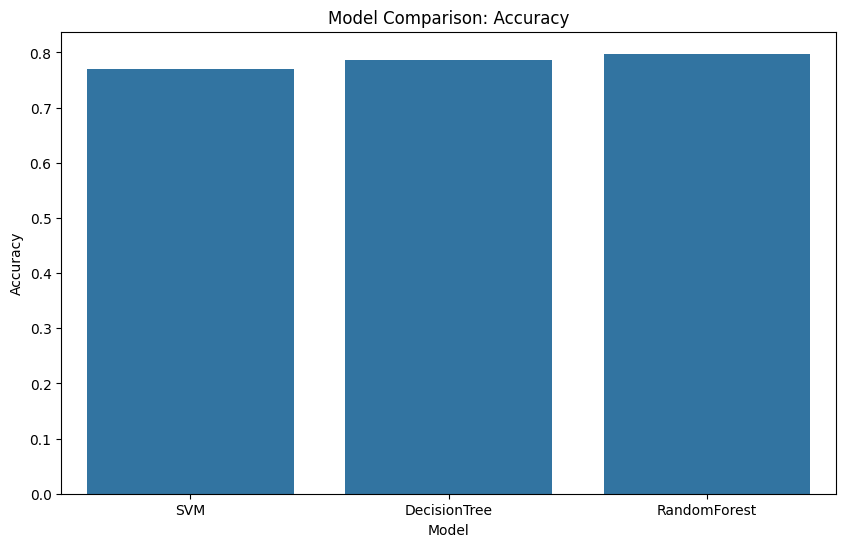

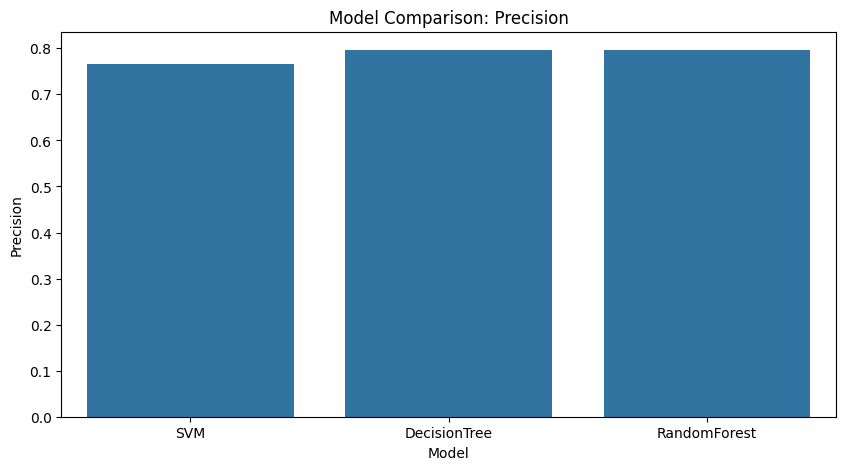

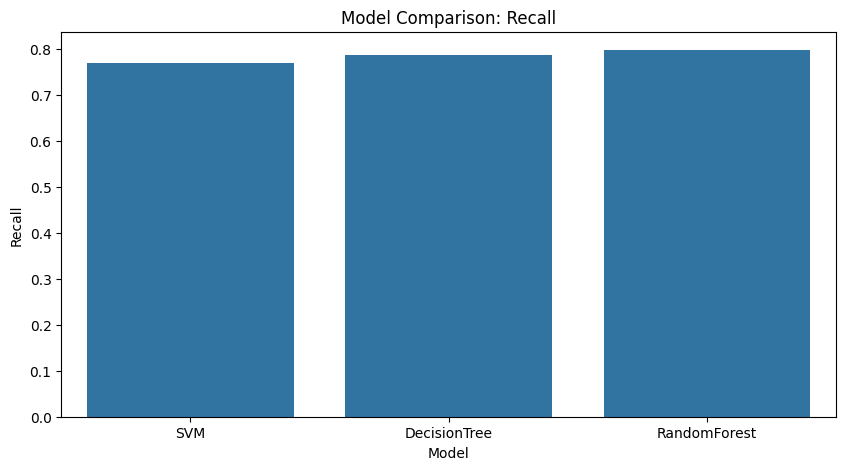

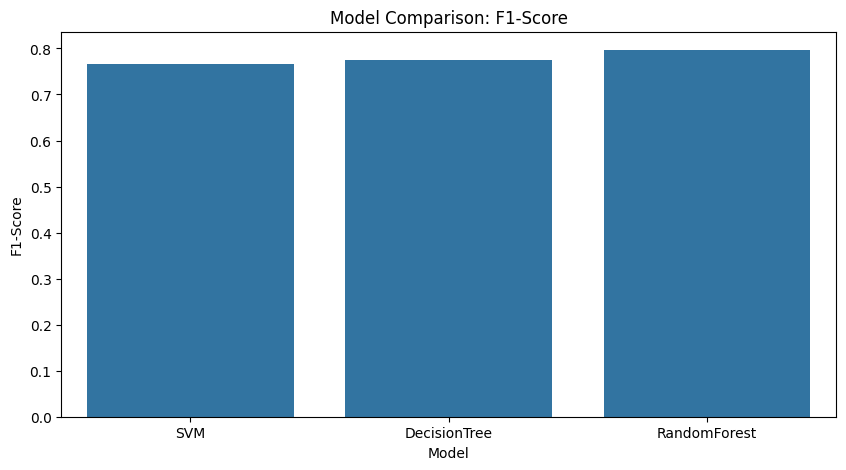

In [ ]:
# Visualizations
plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for metric in metrics:
    sns.barplot(x='Model', y=metric, data=results_df)
    plt.title(f'Model Comparison: {metric}')
    plt.show()

In [ ]:
# Reporting
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print("\nSummary Report:")
print(f"The best-performing model is {best_model['Model']} with an accuracy of {best_model['Accuracy']:.2f}.")
print("\nFindings:")
print("- The choice of hyperparameters significantly impacts the performance.")
print("- Strengths and weaknesses can vary based on the complexity and interpretability of the models. For example, Decision Trees are simple but prone to overfitting, while XGBoost balances performance with interpretability.")


Summary Report:
The best-performing model is RandomForest with an accuracy of 0.80.

Findings:
- The choice of hyperparameters significantly impacts the performance.
- Strengths and weaknesses can vary based on the complexity and interpretability of the models. For example, Decision Trees are simple but prone to overfitting, while XGBoost balances performance with interpretability.
